## Task 2.3: Fundamentals of Visualization Libraries Part 1
#### 1. Install Libraries
#### 2. Read in dataset from previous task
#### 3. Create a line plot of the temperatures for 2022 plotted as time series using the weather dataframe
#### 4. Create a column with the count of trips per day and merge it with the weather dataframe
#### 5. Create a line chart of bike trip counts and temperatures plotted on a dual axis
#### 6. In a markdown cell, briefly explain your code; how did you use Matplotlib to achieve this? Which paradigm did you use?
#### 7. Save Plot as file

### 1. Install Libraries

In [1]:
# Installing libraries
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from datetime import datetime as dt
import matplotlib as mpl

In [2]:
# Checking matplotlib version
import matplotlib
matplotlib.__version__

'3.7.1'

### 2. Read in dataset from previous task

In [3]:
# Importing LaGuardia_data.csv file
df = pd.read_csv('LaGuardia_data.csv')

/var/folders/qg/tbv61t9j3ngdmw6m2qtbk34w0000gn/T/ipykernel_26878/2892705336.py:2: DtypeWarning: Columns (6,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('LaGuardia_data.csv')


In [4]:
df

,Unnamed: 0,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,date,avgTemp,_merge
0,0,9D0DC440CB40CF8E,electric_bike,2022-08-27 13:56:47.728,2022-08-27 14:02:56.651,Flatbush Ave & Ocean Ave,3704.04,3 St & Prospect Park West,3865.05,40.663657,-73.963014,40.668132,-73.973638,casual,2022-08-27,82.04,both
1,1,2214991DFBE5C4D7,electric_bike,2022-08-20 10:37:02.756,2022-08-20 10:45:56.631,Forsyth St\t& Grand St,5382.07,E 11 St & 1 Ave,5746.14,40.717798,-73.993161,40.729538,-73.984267,casual,2022-08-20,82.22,both
2,2,20C5D469563B6337,classic_bike,2022-08-31 18:55:03.051,2022-08-31 19:03:37.344,Perry St & Bleecker St,5922.07,Grand St & Greene St,5500.02,40.735354,-74.004831,40.721700,-74.002381,member,2022-08-31,78.08,both
3,3,3E8791885BC189D1,classic_bike,2022-08-02 08:05:00.250,2022-08-02 08:16:52.063,FDR Drive & E 35 St,6230.04,Grand Army Plaza & Central Park S,6839.1,40.744219,-73.971212,40.764397,-73.973715,member,2022-08-02,79.52,both
4,4,8DBCBF98885106CB,electric_bike,2022-08-25 15:44:48.386,2022-08-25 15:55:39.691,E 40 St & 5 Ave,6474.11,Ave A & E 14 St,5779.11,40.752052,-73.982115,40.730311,-73.980472,member,2022-08-25,82.58,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29838801,29838801,1F223EDAFF420AE3,electric_bike,2022-12-01 20:26:45.847,2022-12-01 20:30:46.012,Avenue D & E 3 St,5436.09,Stanton St & Chrystie St,5523.02,40.720701,-73.977939,40.722293,-73.991475,member,2022-12-01,42.26,both
29838802,29838802,CFA5C560ACB73B8E,classic_bike,2022-12-26 13:46:34.237,2022-12-26 13:52:43.900,43 Ave & 47 St,6209.05,39 Ave & 45 St,6401.03,40.744806,-73.917290,40.749478,-73.918265,member,2022-12-26,23.54,both
29838803,29838803,11C8C5E0DB947B07,classic_bike,2022-12-01 05:56:14.903,2022-12-01 06:06:10.357,Avenue D & E 3 St,5436.09,Bleecker St & Crosby St,5679.08,40.720828,-73.977932,40.726156,-73.995102,member,2022-12-01,42.26,both
29838804,29838804,5B9B083C534A5964,classic_bike,2022-12-02 11:54:15.871,2022-12-02 12:01:00.747,Montague St & Clinton St,4677.06,Sands St & Jay St,4821.03,40.694271,-73.992327,40.700119,-73.986200,member,2022-12-02,38.12,both


In [5]:
print(df.columns)

Index(['Unnamed: 0', 'ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'date', 'avgTemp', '_merge'],
      dtype='object')


In [6]:
# Dropping '_merge' column
df.drop(columns = {'_merge'}, inplace = True)

In [7]:
print(df.columns)

Index(['Unnamed: 0', 'ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'date', 'avgTemp'],
      dtype='object')


In [8]:
# Convert 'date' to datetime format
df['date'] = pd.to_datetime(df['date'])

### 3. Create a line plot of the temperatures for 2022 plotted as time series using the weather dataframe

In [9]:
df_temp = df.copy()

In [10]:
df_temp.dtypes

Unnamed: 0                     int64
ride_id                       object
rideable_type                 object
started_at                    object
ended_at                      object
start_station_name            object
start_station_id              object
end_station_name              object
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
date                  datetime64[ns]
avgTemp                      float64
dtype: object

In [11]:
# Set the 'date' column to be index
df_temp = df.set_index('date')

In [12]:
df_temp.head()

,Unnamed: 0,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,avgTemp
date,,,,,,,,,,,,,,,
2022-08-27,0,9D0DC440CB40CF8E,electric_bike,2022-08-27 13:56:47.728,2022-08-27 14:02:56.651,Flatbush Ave & Ocean Ave,3704.04,3 St & Prospect Park West,3865.05,40.663657,-73.963014,40.668132,-73.973638,casual,82.04
2022-08-20,1,2214991DFBE5C4D7,electric_bike,2022-08-20 10:37:02.756,2022-08-20 10:45:56.631,Forsyth St\t& Grand St,5382.07,E 11 St & 1 Ave,5746.14,40.717798,-73.993161,40.729538,-73.984267,casual,82.22
2022-08-31,2,20C5D469563B6337,classic_bike,2022-08-31 18:55:03.051,2022-08-31 19:03:37.344,Perry St & Bleecker St,5922.07,Grand St & Greene St,5500.02,40.735354,-74.004831,40.721700,-74.002381,member,78.08
2022-08-02,3,3E8791885BC189D1,classic_bike,2022-08-02 08:05:00.250,2022-08-02 08:16:52.063,FDR Drive & E 35 St,6230.04,Grand Army Plaza & Central Park S,6839.1,40.744219,-73.971212,40.764397,-73.973715,member,79.52
2022-08-25,4,8DBCBF98885106CB,electric_bike,2022-08-25 15:44:48.386,2022-08-25 15:55:39.691,E 40 St & 5 Ave,6474.11,Ave A & E 14 St,5779.11,40.752052,-73.982115,40.730311,-73.980472,member,82.58


In [13]:
# Removing unwanted index column
if 'index' in df_temp.columns:
    df_temp.drop(columns=['index'], inplace=True)

In [14]:
print(df_temp.head())

            Unnamed: 0           ride_id  rideable_type  \
date                                                      
2022-08-27           0  9D0DC440CB40CF8E  electric_bike   
2022-08-20           1  2214991DFBE5C4D7  electric_bike   
2022-08-31           2  20C5D469563B6337   classic_bike   
2022-08-02           3  3E8791885BC189D1   classic_bike   
2022-08-25           4  8DBCBF98885106CB  electric_bike   

                         started_at                 ended_at  \
date                                                           
2022-08-27  2022-08-27 13:56:47.728  2022-08-27 14:02:56.651   
2022-08-20  2022-08-20 10:37:02.756  2022-08-20 10:45:56.631   
2022-08-31  2022-08-31 18:55:03.051  2022-08-31 19:03:37.344   
2022-08-02  2022-08-02 08:05:00.250  2022-08-02 08:16:52.063   
2022-08-25  2022-08-25 15:44:48.386  2022-08-25 15:55:39.691   

                  start_station_name start_station_id  \
date                                                    
2022-08-27  Flatbush Av

In [15]:
print(df_temp.columns)

Index(['Unnamed: 0', 'ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'avgTemp'],
      dtype='object')


In [16]:
print(df_temp.index)

DatetimeIndex(['2022-08-27', '2022-08-20', '2022-08-31', '2022-08-02',
               '2022-08-25', '2022-08-24', '2022-08-15', '2022-08-16',
               '2022-08-31', '2022-08-28',
               ...
               '2022-12-04', '2022-12-10', '2022-12-30', '2022-12-19',
               '2022-12-05', '2022-12-01', '2022-12-26', '2022-12-01',
               '2022-12-02', '2022-12-18'],
              dtype='datetime64[ns]', name='date', length=29838806, freq=None)


<Axes: xlabel='date'>

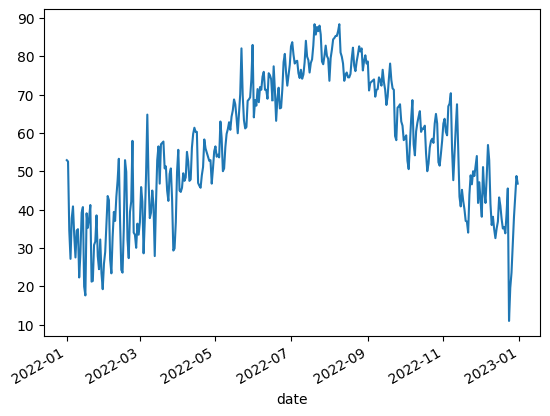

In [17]:
# Due to overlow error msg, updating chunksize to higher value
mpl.rcParams['agg.path.chunksize'] = 10000 

# Filter the DataFrame to include only rows for the specific station
filtered_df = df_temp[df_temp['start_station_name'] == 'Flatbush Ave & Ocean Ave'] 
filtered_df = filtered_df.sort_values(by='date')

# Plot the average temperature for the filtered data
filtered_df['avgTemp'].plot()

### 4. Create a column with the count of trips per day and merge it with the weather dataframe

In [18]:
df_temp.columns

Index(['Unnamed: 0', 'ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'avgTemp'],
      dtype='object')

In [19]:
# Groupby the count of the trips 
df_trip_counts_per_day = pd.DataFrame(df.groupby(['date'])['ride_id'].count()).reset_index()

In [20]:
df_trip_counts_per_day.head(100)

,date,ride_id
0,2022-01-01,20763
1,2022-01-02,42458
2,2022-01-03,33201
3,2022-01-04,36616
4,2022-01-05,34609
...,...,...
95,2022-04-06,48279
96,2022-04-07,35519
97,2022-04-08,87615
98,2022-04-09,67572


In [21]:
# Merge the trip counts with the weather DataFrame
df_trip_counts_per_day.rename(columns = {'ride_id':'bike_rides_daily'}, inplace = True)
df = df.merge(df_trip_counts_per_day, on = "date", how = 'outer', indicator = True)
print(df['_merge'].value_counts(dropna = False))
print("Shape of January 1st is", df[df['date'] == '2022-01-01'].shape) # Check 
print("Shape of January 2nd is", df[df['date'] == '2022-01-02'].shape) # Second check 

df_temp = df.set_index('date')

print(df_temp.columns)

_merge
both          29838806
left_only            0
right_only           0
Name: count, dtype: int64
Shape of January 1st is (20763, 18)
Shape of January 2nd is (42458, 18)
Index(['Unnamed: 0', 'ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'avgTemp', 'bike_rides_daily', '_merge'],
      dtype='object')


In [22]:
df_temp.head(1000)

,Unnamed: 0,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,avgTemp,bike_rides_daily,_merge
date,,,,,,,,,,,,,,,,,
2022-01-01,27222243,ECDFB9C97FAF0F35,classic_bike,2022-01-01 13:38:37.927,2022-01-01 13:45:58.200,W 13 St & 7 Ave,6030.04,Great Jones St,5636.11,40.737815,-73.999947,40.727434,-73.993790,casual,52.88,20763,both
2022-01-01,27222411,22F675B5C5A666FD,classic_bike,2022-01-01 00:18:07.680,2022-01-01 01:19:41.047,W 42 St & Dyer Ave,6644.07,West St & Chambers St,5329.03,40.758985,-73.993800,40.717548,-74.013221,casual,52.88,20763,both
2022-01-01,27222488,38347DF656A7074B,classic_bike,2021-12-31 22:46:20.965,2022-01-01 01:17:51.394,University Pl & E 14 St,5905.14,W 110 St & Amsterdam Ave,7646.04,40.734814,-73.992085,40.802692,-73.962950,casual,52.88,20763,both
2022-01-01,27222685,39DBCC00E8BCCFCF,classic_bike,2022-01-01 22:40:32.125,2022-01-01 22:46:53.380,8 Ave & W 27 St,6297.07,E 31 St & 3 Ave,6239.08,40.747968,-73.996637,40.743943,-73.979661,member,52.88,20763,both
2022-01-01,27222714,FB8B1C38D9B41889,electric_bike,2022-01-01 14:46:57.116,2022-01-01 14:53:41.673,University Pl & E 14 St,5905.14,E 31 St & 3 Ave,6239.08,40.734814,-73.992085,40.743943,-73.979661,member,52.88,20763,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-01,28268745,AC7AF19AC53F3DEE,classic_bike,2021-12-31 23:53:33.397,2022-01-01 00:04:44.031,Broadway & E 14 St,5905.12,6 Ave & W 34 St,6364.1,40.734546,-73.990741,40.749640,-73.988050,member,52.88,20763,both
2022-01-01,28268830,72543A0279889F5B,electric_bike,2022-01-01 00:13:18.145,2022-01-01 01:25:13.965,Water St & Main St,4936.14,6 Ave & W 34 St,6364.1,40.703212,-73.990409,40.749640,-73.988050,casual,52.88,20763,both
2022-01-01,28268866,DF97688105200BB3,electric_bike,2022-01-01 19:23:46.844,2022-01-01 19:45:54.988,Greene Ave & Nostrand Ave,4519.02,Canal St & Rutgers St,5303.08,40.688334,-73.950916,40.714275,-73.989900,member,52.88,20763,both


### 5. Create a line chart of bike trip counts and temperatures plotted on a dual axis

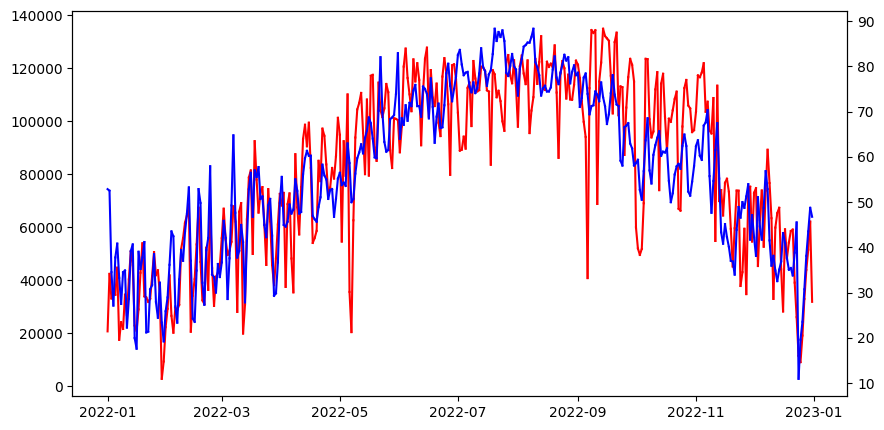

In [23]:
# Create figure and axis objects with subplots()
fig,ax = plt.subplots(figsize=(10, 5))

# Create a plot of the bike rides
ax.plot(df_temp['bike_rides_daily'],color = "red")

# Create the dual axis
ax2 = ax.twinx()

# Create a plot with the temperatues on the y-axis using second axis object
ax2.plot(df_temp["avgTemp"], color = "blue")
plt.show()

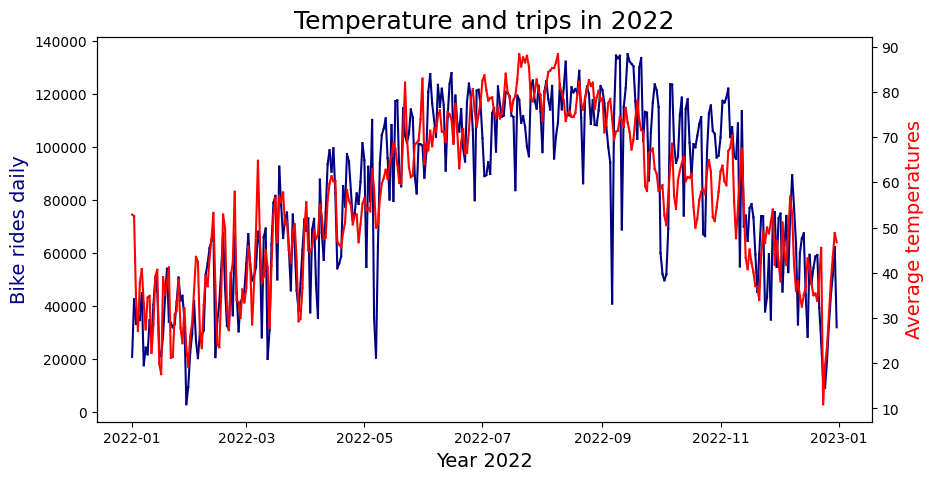

In [24]:
# Create figure and axis objects with subplots() and details
fig,ax = plt.subplots(figsize=(10, 5))

# Create a plot of the bike rides
ax.plot(df_temp['bike_rides_daily'],color = "navy")
ax.set_xlabel("Year 2022", fontsize = 14) # set x-axis label
ax.set_ylabel("Bike rides daily",color = "navy", fontsize = 14) # set y-axis label

# Create the dual axis 
ax2 = ax.twinx()

# Make a plot with the temperatues on the y-axis using second axis object
ax2.plot(df_temp["avgTemp"], color = "red")
ax2.set_ylabel("Average temperatures", color = "red",fontsize=14)
plt.title('Temperature and trips in 2022', fontsize = 18)
plt.show()

### 6. In a markdown cell, briefly explain your code; how did you use Matplotlib to achieve this? Which paradigm did you use?

#### I used Matplotlib's Object-Oriented Approach to create two figures that visualize the relationship between bike rides and average temperatures. The first plot visualizes both bike rides and average temperatures on a dual y-axis. The second plot adds labels and a title to better describe the data, along with customized colors—navy for bike rides and red for temperatures—to distinguish between the two datasets. This approach allowed me to create dual-axis plots, manage each figure element (such as labels, colors, and titles) in an organized manner, and clearly differentiate the data by using separate axis objects.